<a href="https://colab.research.google.com/github/antobaez850/Ventas_Ecommerce_Limpieza/blob/main/Ventas_ecommerce_limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problema del negocio**

Una empresa de e-commerce que vende en varias categorías (Electrónica, Hogar, Indumentaria, Deportes, Juguetes, Belleza) a través de 3 canales (Web, App, Marketplace). El equipo comercial está viendo que la rentabilidad no crece al ritmo esperado y sospecha que hay problemas de devoluciones y descuentos mal aplicados, pero no tienen data confiable para confirmarlo.

## **Pregunta a responder**
¿Qué categorías, canales o segmentos de clientes tienen mayor tasa de devolución y cómo se relaciona eso con el descuento aplicado y el tiempo de entrega? ¿Dónde conviene enfocar acciones para reducir devoluciones sin resignar ventas?

### **Data Set**
ventas_ecommerce.csv

**Filas: 5075 -
Columnas: 15**

*   id_pedido,id_cliente: identificatorio

*   fecha: fecha pedido

*   edad_cliente

*   categoria_producto,canal_venta,region,metodo_pago: dim categoricas

*   precio_unitario, cantidad, descuento_pct, monto_total: variables monetarias

*   dias_entrega: tiempo de entrega

*   rating: calificacion 1-5 (puede faltar)

*   devuelto: 1 si el pedido fue devuelto

In [2]:
import pandas as pd # Para leer los datos
import matplotlib.pyplot as plt # Graficas
import seaborn as sns # Graficas
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/Ventas_ecommerce/ventas_ecommerce.csv", sep=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Ver caracteristicas generales
print(data.shape)
data.head()

(5075, 15)


,id_pedido,fecha,id_cliente,edad_cliente,categoria_producto,canal_venta,region,metodo_pago,precio_unitario,cantidad,descuento_pct,dias_entrega,rating,devuelto,monto_total
0,PED-12701,2024-07-27,1628,33.0,Electrónica,Web,Córdoba,Tarjeta de crédito,285647.94,3,0,6.0,NaN,0,856943.82
1,PED-12128,2024-06-09,1508,46.0,Juguetes,web,CABA,Tarjeta de crédito,24164.27,1,15,8.0,5.0,0,20539.63
2,PED-10050,04/02/2024,2491,46.0,Belleza,App,GBA,MercadoPago,18852.60,1,0,6.0,4.0,1,18852.60
3,PED-11758,2024-07-24,1883,67.0,Belleza,Web,Santa Fe,Efectivo,28391.75,3,0,7.0,5.0,0,85175.25
4,PED-12142,2025-05-28,2585,28.0,Electrónica,Marketplace,CABA,Transferencia,229375.37,1,0,2.0,3.0,0,229375.37


In [4]:
#Ver variables categoricas y las numericas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5075 entries, 0 to 5074
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           5075 non-null   object 
 1   fecha               5075 non-null   object 
 2   id_cliente          5075 non-null   int64  
 3   edad_cliente        4872 non-null   float64
 4   categoria_producto  5075 non-null   object 
 5   canal_venta         4999 non-null   object 
 6   region              4922 non-null   object 
 7   metodo_pago         4973 non-null   object 
 8   precio_unitario     5075 non-null   float64
 9   cantidad            5075 non-null   int64  
 10  descuento_pct       5075 non-null   int64  
 11  dias_entrega        4922 non-null   float64
 12  rating              4561 non-null   float64
 13  devuelto            5075 non-null   int64  
 14  monto_total         5075 non-null   float64
dtypes: float64(5), int64(4), object(6)
memory usage: 594.9+

## **Limpieza de datos**

**1. Normalización de texto en columnas categóricas**

Que no haya categorias en Mayusculas y minisculas, Eliminar espacios, que no haya abreviaciones.

Para esto vamos a graficar las categorias para evaluar.



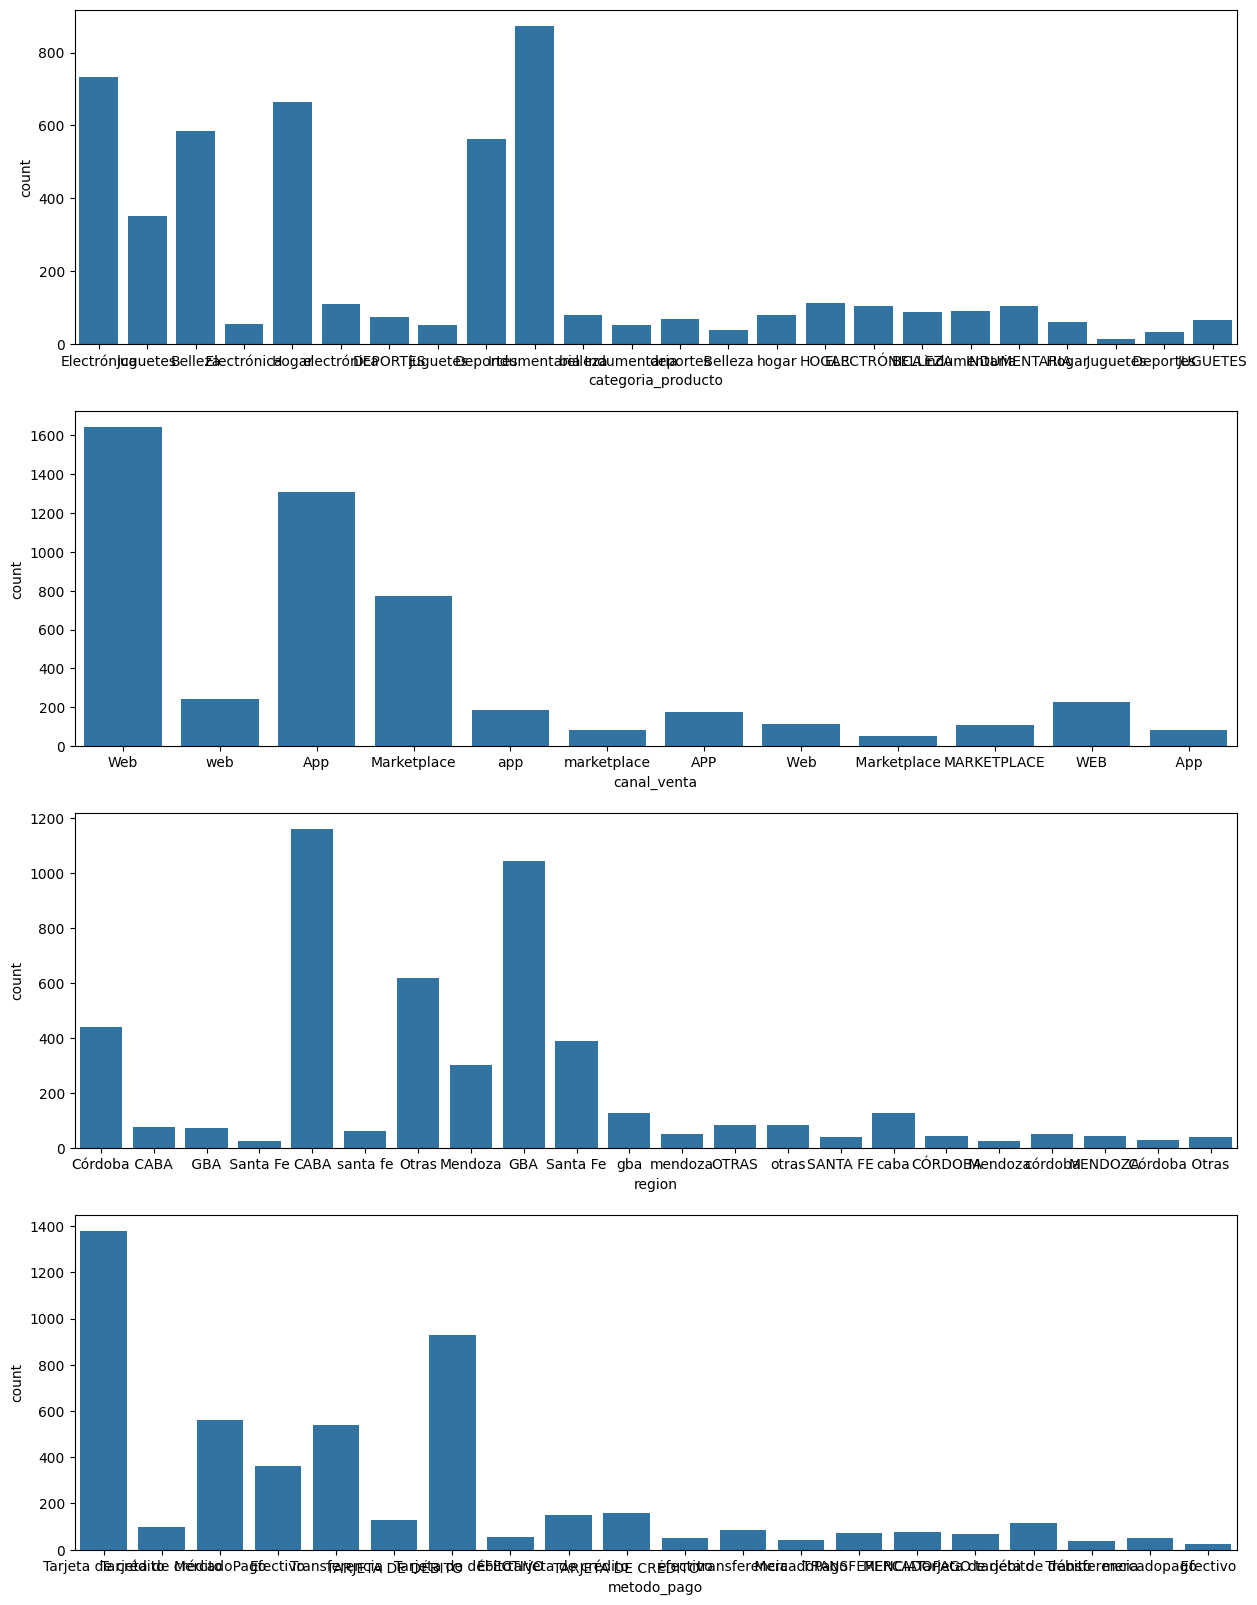

In [4]:
cols_cat = ["categoria_producto", "canal_venta", "region", "metodo_pago"]
figm , ax = plt.subplots(nrows=4, ncols=1, figsize=(15,20))

for i, col in enumerate(cols_cat):
    sns.countplot(data=data, x=col, ax=ax[i])

In [ ]:
#Revisar que la fecha tenga el mismo formato
#data["fecha"].sample(20, random_state=1).tolist()
resultado = pd.to_datetime(data["fecha"], format="%Y-%m-%d", errors="coerce")
print("No matchean el formato esperado:", resultado.isna().sum())

No matchean el formato esperado: 0



Se detectó:
*   Inconsistencias de texto: mayúsculas/minúsculas y espacios extra en columnas categóricas (ej. " web ", "HOGAR")
*   Fechas en dos formatos distintos (YYYY-MM-DD y DD/MM/YYYY)


In [5]:
cols_texto = ["categoria_producto", "canal_venta", "region", "metodo_pago"]
for col in cols_texto:
    data[col] = data[col].str.strip().str.title()

In [6]:
def parsear_fecha(f):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(f, format=fmt)
        except ValueError:
            continue
    return pd.NaT

data["fecha"] = data["fecha"].apply(parsear_fecha)
print("Fechas no parseadas:", data["fecha"].isna().sum())

Fechas no parseadas: 0



**2. Filas repetidas**



In [8]:
print(f'Tamaño real del data set: {data.shape}')
data.drop_duplicates(inplace = True)
print(f'Tamaño real del data set sin filas repetidas: {data.shape}')

Tamaño real del data set: (5004, 15)
Tamaño real del data set sin filas repetidas: (5004, 15)


**3. Outliers en variables numericas**



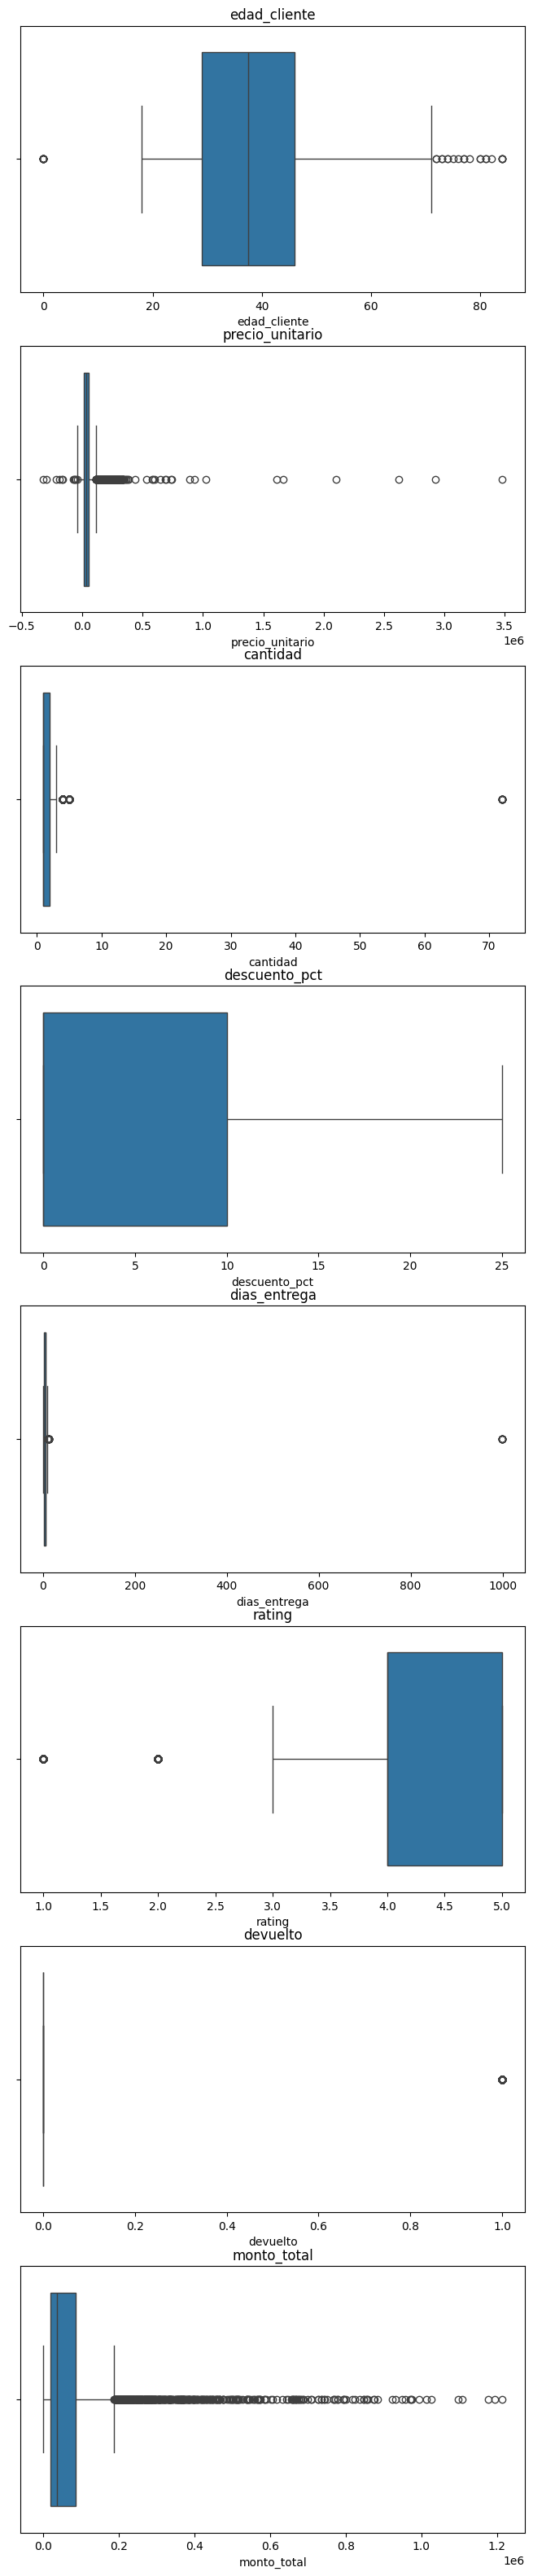

In [ ]:
#Generar graficas individuales para detectar outliers

cols_num = ['edad_cliente',	'precio_unitario',	'cantidad',	'descuento_pct',	'dias_entrega',	'rating',	'devuelto',	'monto_total']

fig, ax = plt.subplots(nrows=8, ncols=1, figsize=(8,40))

for i, col in enumerate(cols_num):
    sns.boxplot(data=data, x=col, ax=ax[i])
    ax[i].set_title(col)

**4. Valores imposibles y outliers**

Se detecta:

*   edad_cliente = 0
*   precio_unitario < 0
*   dias_entrega = 999
*   monto_total inconsistente con precio×cantidad en algunas filas (quedó en 0 por error de sistema)
*   Outlier en precio_unitario y cantidad


In [ ]:
 # edades imposibles -> NaN
data.loc[(data["edad_cliente"] <= 0) | (data["edad_cliente"] > 100), "edad_cliente"] = np.nan

# precios negativos -> probablemente el valor absoluto es el correcto (error de signo)
neg_mask = data["precio_unitario"] < 0
print("Precios negativos corregidos:", neg_mask.sum())
data.loc[neg_mask, "precio_unitario"] = data.loc[neg_mask, "precio_unitario"].abs()

# 999 en dias_entrega es un código de error, no un dato real -> a NaN
data.loc[data["dias_entrega"] == 999, "dias_entrega"] = np.nan

# RECALCULAR monto_total DONDE ESTÁ INCONSISTENTE
monto_esperado = (data["precio_unitario"] * data["cantidad"] * (1 - data["descuento_pct"] / 100)).round(2)
inconsistentes = (data["monto_total"] - monto_esperado).abs() > 1
print("Filas con monto_total inconsistente:", inconsistentes.sum())
data.loc[inconsistentes, "monto_total"] = monto_esperado[inconsistentes]

Precios negativos corregidos: 20
Filas con monto_total inconsistente: 91


In [ ]:
# EXPLICAR!. OUTLIERS EN PRECIO Y CANTIDAD (método IQR POR CATEGORÍA)
# ------------------------------------------------------------------
# OJO: el precio de Electrónica y el de Belleza viven en escalas muy distintas.
# Calcular el IQR sobre todo el dataset mezclado castigaría como "outlier" a
# productos caros que en realidad son normales dentro de su categoría.
# Por eso el límite se calcula POR categoria_producto.
def limites_iqr(serie, k=3):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

limites_por_cat = data.groupby("categoria_producto")["precio_unitario"].apply(
    lambda s: pd.Series(limites_iqr(s), index=["lim_inf", "lim_sup"])
).unstack()
print("\nLímites de precio por categoría:\n", limites_por_cat.round(0))

data = data.merge(limites_por_cat, on="categoria_producto", how="left")
outliers_precio = data[(data["precio_unitario"] < data["lim_inf"]) | (data["precio_unitario"] > data["lim_sup"])]
print("\nOutliers de precio (por categoría):", len(outliers_precio))

# cantidad: valores > 20 no son razonables para venta minorista individual
outliers_cant = data[data["cantidad"] > 20]
print("Outliers de cantidad (>20 unidades):", len(outliers_cant))

# Decisión: capear (winsorizar) por categoría en vez de eliminar filas
data["precio_unitario"] = data["precio_unitario"].clip(lower=data["lim_inf"], upper=data["lim_sup"])
data["cantidad"] = data["cantidad"].clip(upper=20)
data = data.drop(columns=["lim_inf", "lim_sup"])


Límites de precio por categoría:
                      lim_inf   lim_sup
categoria_producto                    
Belleza              -7790.0   31812.0
Deportes            -22895.0   98766.0
Electrónica        -114184.0  470210.0
Hogar               -25417.0  115861.0
Indumentaria        -16060.0   66925.0
Juguetes            -10742.0   40205.0

Outliers de precio (por categoría): 25
Outliers de cantidad (>20 unidades): 15


**5. Análisis de columnas**

En este caso no tenemos columnas irrelevantes.

In [ ]:
#Conteo de los niveles en columnas categoricas(puede haber columnas que tengan el mismo valor para todos los registros, en esos casos no es relevante)
cols_cat = ['id_pedido','fecha','categoria_producto',	'canal_venta',	'region','metodo_pago']

for col in cols_cat:
  print(f'Columna {col}: {data[col].nunique()} subniveles')

Columna id_pedido: 5000 subniveles
Columna fecha: 545 subniveles
Columna categoria_producto: 6 subniveles
Columna canal_venta: 3 subniveles
Columna region: 6 subniveles
Columna metodo_pago: 5 subniveles


In [ ]:
#Conteo para columnas numericas, un ejemplo para saber si tiene un mismo valor para toda la fila es que la std(dev standar) sea igual a 0
data.describe()

,fecha,id_cliente,edad_cliente,precio_unitario,cantidad,descuento_pct,dias_entrega,rating,devuelto,monto_total
count,5004,5004.000000,4789.00000,5004.00000,5004.000000,5004.000000,4844.000000,4500.000000,5004.000000,5.004000e+03
mean,2024-09-29 07:27:28.920863232,1888.719025,37.89455,58533.16290,1.534173,4.499400,4.639761,4.054667,0.087330,9.389281e+04
min,2024-01-01 00:00:00,1000.000000,18.00000,500.00000,1.000000,0.000000,1.000000,1.000000,0.000000,4.000000e+02
25%,2024-05-16 00:00:00,1437.000000,29.00000,16837.88000,1.000000,0.000000,3.000000,4.000000,0.000000,1.985342e+04
50%,2024-09-29 00:00:00,1885.000000,38.00000,31565.62000,1.000000,0.000000,5.000000,4.000000,0.000000,3.758887e+04
75%,2025-02-13 00:00:00,2327.500000,46.00000,55968.71000,2.000000,10.000000,6.000000,5.000000,0.000000,9.049576e+04
max,2025-06-28 00:00:00,2799.000000,84.00000,470209.64000,20.000000,25.000000,13.000000,5.000000,1.000000,5.267961e+06
std,NaN,518.738817,12.32725,69626.43743,1.345342,7.081251,2.331339,1.136451,0.282346,2.151692e+05


**6. Datos Faltantes (Análisis de registros)**

Los datos no estan completos para todas las columnas, todas deberian tener 5075 registros pero para el caso de de "edad_cliente", "canal_venta", "region", "metodo_pago", "dias_entrega", "rating" hay menos registros.

No se van a eliminar registros por que es alto el % de faltantes por ejemplo en rating, a continuacion se detalla que accion aplica para cada columna.

*   rating(10%): Crear una categoria "sin rating", no sirve imputar con un nro
inventado ya que podria distorcionar el promedio.
*   region, metodo_pago, canal_venta(1,5-3%): Imputar con la moda o como "Desconocido".
*   edad(4%): Imputar con mediana o dejar como "Desconocido".
*   dias_entrega(3%): Ojo por que aca tiene como valor 999(outlier). Tratar como NaN e imputar con mediana.




In [ ]:
# Categóricas de bajo impacto -> imputar como "Desconocido"
for col in ["region", "metodo_pago", "canal_venta"]:
    data[col] = data[col].fillna("Desconocido")

# edad_cliente -> mediana
data["edad_cliente"] = data["edad_cliente"].fillna(data["edad_cliente"].median())

# dias_entrega -> mediana por región (más preciso que mediana global)
data["dias_entrega"] = data.groupby("region")["dias_entrega"].transform(
    lambda x: x.fillna(x.median())
)
data["dias_entrega"] = data["dias_entrega"].fillna(data["dias_entrega"].median())

# rating: NO imputamos con un número (distorsiona el promedio).
# Creamos una bandera indicadora, útil porque puede estar correlacionada con devoluciones.
data["rating_faltante"] = data["rating"].isna().astype(int)

In [ ]:
data.shape

(5004, 16)

Limpieza finalizada.

Cantidad de registros originales 5075 y 15 columas.

Data set resultante contiene 5004 registros y 16 columnas.

Ya esta listo para comenzar el Analisis Exploratorio

In [ ]:
ruta = "/content/drive/MyDrive/Ventas_ecommerce/ventas_ecommerce_clean.csv"
data.to_csv(ruta)